# Analisis Senyar Cylone

In [1]:
from pathlib import Path
import glob
import os

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# file path proyek yang akan digunakan
path_top = Path("D:/ERA5_REANALYSIS")

In [3]:
# melihat data single layer harian ERA5_Reanalysis
ds = xr.open_dataset(path_top / "ERA5_SingleLevel_DailyMeanandSum_20250101-20260331.nc", engine="netcdf4")
display(ds)

<xarray.Dataset> Size: 217MB
Dimensions:     (valid_time: 455, latitude: 50, longitude: 77)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 400B 10.75 10.5 10.25 ... -1.0 -1.25 -1.5
  * longitude   (longitude) float64 616B 93.0 93.25 93.5 ... 111.5 111.8 112.0
    number      int64 8B ...
Data variables: (12/31)
    u100        (valid_time, latitude, longitude) float32 7MB ...
    v100        (valid_time, latitude, longitude) float32 7MB ...
    u10n        (valid_time, latitude, longitude) float32 7MB ...
    u10         (valid_time, latitude, longitude) float32 7MB ...
    v10n        (valid_time, latitude, longitude) float32 7MB ...
    v10         (valid_time, latitude, longitude) float32 7MB ...
    ...          ...
    tvh         (valid_time, latitude, longitude) float32 7MB ...
    tvl         (valid_time, latitude, longitude) float32 7MB ...
    swvl1       (valid_time, latitude, longitude) float32 7MB ...
    swvl2       (valid_time, latitude, longitude) float32 7MB ...
    swvl3       (valid_time, latitude, longitude) float32 7MB ...
    swvl4       (valid_time, latitude, longitude) float32 7MB ...

### Contoh : Kota Medan

In [4]:
# get the latitude and longitude bounds for Medan city
lat_min, lat_max = 3.3833, 3.7500  # Approximate latitude bounds for Medan
lon_min, lon_max = 98.3333, 98.7500  # Approximate longitude bounds for Medan

# Select data within the specified bounds
ds_medan = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# Display the selected dataset
print("Dataset for Medan:")
display(ds_medan)

# Calculate the number of grid points
num_grids = len(ds_medan.latitude) * len(ds_medan.longitude)
print(f"Number of grids used: {num_grids}")

# Convert to DataFrame
df_medan = ds_medan.to_dataframe().reset_index()
print("\nDataFrame for Medan:")
display(df_medan)

Dataset for Medan:


<xarray.Dataset> Size: 229kB
Dimensions:     (valid_time: 455, latitude: 2, longitude: 2)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 16B 3.75 3.5
  * longitude   (longitude) float64 16B 98.5 98.75
    number      int64 8B ...
Data variables: (12/31)
    u100        (valid_time, latitude, longitude) float32 7kB ...
    v100        (valid_time, latitude, longitude) float32 7kB ...
    u10n        (valid_time, latitude, longitude) float32 7kB ...
    u10         (valid_time, latitude, longitude) float32 7kB ...
    v10n        (valid_time, latitude, longitude) float32 7kB ...
    v10         (valid_time, latitude, longitude) float32 7kB ...
    ...          ...
    tvh         (valid_time, latitude, longitude) float32 7kB ...
    tvl         (valid_time, latitude, longitude) float32 7kB ...
    swvl1       (valid_time, latitude, longitude) float32 7kB ...
    swvl2       (valid_time, latitude, longitude) float32 7kB ...
    swvl3       (valid_time, latitude, longitude) float32 7kB ...
    swvl4       (valid_time, latitude, longitude) float32 7kB ...

Number of grids used: 4

DataFrame for Medan:


,valid_time,latitude,longitude,u100,v100,u10n,u10,v10n,v10,d2m,...,tclw,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number
0,2025-01-01,3.75,98.50,1.068951,-0.314060,0.504612,0.577389,-0.230350,-0.077847,297.607483,...,0.073273,0.001495,0.000590,6.0,1.0,0.408256,0.413693,0.418091,0.424625,0
1,2025-01-01,3.75,98.75,1.730816,-0.766453,0.812229,0.852047,-0.704227,-0.503872,297.966370,...,0.049057,0.002228,0.000862,6.0,1.0,0.424888,0.431805,0.423523,0.443874,0
2,2025-01-01,3.50,98.50,1.020611,-0.483494,0.470921,0.524899,0.215694,0.311314,296.206116,...,0.113022,0.002350,0.001467,6.0,1.0,0.398418,0.403366,0.420986,0.429108,0
3,2025-01-01,3.50,98.75,2.098248,-0.485935,0.953098,0.996822,-0.044315,0.106236,296.645569,...,0.104240,0.000885,0.003532,6.0,1.0,0.424282,0.430962,0.412083,0.449337,0
4,2025-01-02,3.75,98.50,1.815887,-1.117908,0.930264,0.984680,-0.691376,-0.609913,297.935181,...,0.142471,0.004547,0.003859,6.0,1.0,0.398987,0.401205,0.414145,0.424240,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,2026-03-30,3.50,98.75,-0.833660,1.140862,NaN,NaN,0.922356,0.921997,297.612183,...,0.070389,0.001129,0.008347,6.0,1.0,0.352856,0.284421,0.274073,0.398453,0
1816,2026-03-31,3.75,98.50,-0.774933,-0.165180,NaN,NaN,0.136150,0.074902,297.847412,...,0.070824,0.006195,0.005151,6.0,1.0,0.319237,0.285139,0.284910,0.367722,0
1817,2026-03-31,3.75,98.75,-1.088898,0.341412,NaN,NaN,0.419598,0.381298,297.821045,...,0.041374,0.001282,0.005711,6.0,1.0,0.394364,0.338659,0.346708,0.402294,0
1818,2026-03-31,3.50,98.50,-0.800079,0.250591,NaN,NaN,0.500652,0.414013,296.146729,...,0.087669,0.010803,0.006601,6.0,1.0,0.396851,0.361761,0.280874,0.376953,0


,valid_time,latitude,longitude,u100,v100,u10n,u10,v10n,v10,d2m,...,tclw,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number
0,2025-01-01,3.625,98.625,1.479656,-0.512486,0.685215,0.737789,-0.190800,-0.041042,297.106384,...,0.084898,0.001740,0.001613,6.0,1.0,0.413961,0.419957,0.418671,0.436736,0.0
1,2025-01-02,3.625,98.625,2.084991,-1.309742,0.980251,1.058228,-0.718475,-0.624744,297.731445,...,0.156357,0.011848,0.005488,6.0,1.0,0.407866,0.409235,0.414590,0.436193,0.0
2,2025-01-03,3.625,98.625,3.023396,-0.478245,1.575836,1.604748,-0.006859,0.067612,297.661194,...,0.257616,0.018585,0.005667,6.0,1.0,0.418203,0.414524,0.411155,0.435646,0.0
3,2025-01-04,3.625,98.625,0.738224,-0.343590,0.023254,0.137348,-0.101223,0.040268,297.536987,...,0.166420,0.005020,0.009420,6.0,1.0,0.414211,0.416540,0.408321,0.435102,0.0
4,2025-01-05,3.625,98.625,-0.880718,0.061317,-0.357937,-0.319496,0.227398,0.252544,297.764282,...,0.073118,0.014137,0.018980,6.0,1.0,0.421096,0.423751,0.407620,0.434515,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2026-03-27,3.625,98.625,1.670738,-0.399265,NaN,NaN,-0.100006,-0.001007,296.783997,...,0.034958,0.000168,0.000164,6.0,1.0,0.259181,0.294474,0.302102,0.387923,0.0
451,2026-03-28,3.625,98.625,0.947590,0.327297,NaN,NaN,0.226406,0.318268,297.453857,...,0.097977,0.003380,0.007165,6.0,1.0,0.289485,0.288340,0.300638,0.387500,0.0
452,2026-03-29,3.625,98.625,-0.821697,0.724987,NaN,NaN,0.605732,0.568947,297.527771,...,0.154362,0.005463,0.007957,6.0,1.0,0.345517,0.293268,0.298939,0.387089,0.0
453,2026-03-30,3.625,98.625,-0.827984,0.628166,NaN,NaN,0.648552,0.580505,297.825195,...,0.065815,0.002060,0.009893,6.0,1.0,0.347716,0.302342,0.296844,0.386654,0.0


,valid_time,latitude,longitude,u100,v100,u10n,u10,v10n,v10,d2m,...,tclw,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number
0,2025-01-01,3.625,98.625,1.479656,-0.512486,0.685215,0.737789,-0.190800,-0.041042,297.106384,...,0.084898,0.001740,0.001613,6.0,1.0,0.413961,0.419957,0.418671,0.436736,0.0
1,2025-01-02,3.625,98.625,2.084991,-1.309742,0.980251,1.058228,-0.718475,-0.624744,297.731445,...,0.156357,0.011848,0.005488,6.0,1.0,0.407866,0.409235,0.414590,0.436193,0.0
2,2025-01-03,3.625,98.625,3.023396,-0.478245,1.575836,1.604748,-0.006859,0.067612,297.661194,...,0.257616,0.018585,0.005667,6.0,1.0,0.418203,0.414524,0.411155,0.435646,0.0
3,2025-01-04,3.625,98.625,0.738224,-0.343590,0.023254,0.137348,-0.101223,0.040268,297.536987,...,0.166420,0.005020,0.009420,6.0,1.0,0.414211,0.416540,0.408321,0.435102,0.0
4,2025-01-05,3.625,98.625,-0.880718,0.061317,-0.357937,-0.319496,0.227398,0.252544,297.764282,...,0.073118,0.014137,0.018980,6.0,1.0,0.421096,0.423751,0.407620,0.434515,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2026-03-27,3.625,98.625,1.670738,-0.399265,NaN,NaN,-0.100006,-0.001007,296.783997,...,0.034958,0.000168,0.000164,6.0,1.0,0.259181,0.294474,0.302102,0.387923,0.0
451,2026-03-28,3.625,98.625,0.947590,0.327297,NaN,NaN,0.226406,0.318268,297.453857,...,0.097977,0.003380,0.007165,6.0,1.0,0.289485,0.288340,0.300638,0.387500,0.0
452,2026-03-29,3.625,98.625,-0.821697,0.724987,NaN,NaN,0.605732,0.568947,297.527771,...,0.154362,0.005463,0.007957,6.0,1.0,0.345517,0.293268,0.298939,0.387089,0.0
453,2026-03-30,3.625,98.625,-0.827984,0.628166,NaN,NaN,0.648552,0.580505,297.825195,...,0.065815,0.002060,0.009893,6.0,1.0,0.347716,0.302342,0.296844,0.386654,0.0


,valid_time,tp,lsp,sp,t2m
0,2025-01-01,1.612902,0.432014,1003.847046,26.996857
1,2025-01-02,5.488157,1.732349,1003.490784,27.410126
2,2025-01-03,5.666614,0.902295,1004.040466,26.611359
3,2025-01-04,9.419680,0.544190,1003.803284,26.545380
4,2025-01-05,18.979549,0.891089,1004.053894,26.529633
...,...,...,...,...,...
450,2026-03-27,0.163913,0.031829,1002.281433,27.864349
451,2026-03-28,7.164717,0.999093,1001.943726,26.809967
452,2026-03-29,7.957101,2.534747,1002.524231,26.802032
453,2026-03-30,9.893060,0.139356,1003.029236,27.277069


,valid_time,latitude,longitude,u100,v100,u10n,u10,v10n,v10,d2m,...,tclw,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number
0,2025-01-01,3.625,98.625,1.479656,-0.512486,0.685215,0.737789,-0.190800,-0.041042,297.106384,...,0.084898,0.001740,0.001613,6.0,1.0,0.413961,0.419957,0.418671,0.436736,0.0
1,2025-01-02,3.625,98.625,2.084991,-1.309742,0.980251,1.058228,-0.718475,-0.624744,297.731445,...,0.156357,0.011848,0.005488,6.0,1.0,0.407866,0.409235,0.414590,0.436193,0.0
2,2025-01-03,3.625,98.625,3.023396,-0.478245,1.575836,1.604748,-0.006859,0.067612,297.661194,...,0.257616,0.018585,0.005667,6.0,1.0,0.418203,0.414524,0.411155,0.435646,0.0
3,2025-01-04,3.625,98.625,0.738224,-0.343590,0.023254,0.137348,-0.101223,0.040268,297.536987,...,0.166420,0.005020,0.009420,6.0,1.0,0.414211,0.416540,0.408321,0.435102,0.0
4,2025-01-05,3.625,98.625,-0.880718,0.061317,-0.357937,-0.319496,0.227398,0.252544,297.764282,...,0.073118,0.014137,0.018980,6.0,1.0,0.421096,0.423751,0.407620,0.434515,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2026-03-27,3.625,98.625,1.670738,-0.399265,NaN,NaN,-0.100006,-0.001007,296.783997,...,0.034958,0.000168,0.000164,6.0,1.0,0.259181,0.294474,0.302102,0.387923,0.0
451,2026-03-28,3.625,98.625,0.947590,0.327297,NaN,NaN,0.226406,0.318268,297.453857,...,0.097977,0.003380,0.007165,6.0,1.0,0.289485,0.288340,0.300638,0.387500,0.0
452,2026-03-29,3.625,98.625,-0.821697,0.724987,NaN,NaN,0.605732,0.568947,297.527771,...,0.154362,0.005463,0.007957,6.0,1.0,0.345517,0.293268,0.298939,0.387089,0.0
453,2026-03-30,3.625,98.625,-0.827984,0.628166,NaN,NaN,0.648552,0.580505,297.825195,...,0.065815,0.002060,0.009893,6.0,1.0,0.347716,0.302342,0.296844,0.386654,0.0


,valid_time,tp,lsp,sp,t2m
0,2025-01-01,1.612902,0.432014,1003.847046,26.996857
1,2025-01-02,5.488157,1.732349,1003.490784,27.410126
2,2025-01-03,5.666614,0.902295,1004.040466,26.611359
3,2025-01-04,9.419680,0.544190,1003.803284,26.545380
4,2025-01-05,18.979549,0.891089,1004.053894,26.529633
...,...,...,...,...,...
450,2026-03-27,0.163913,0.031829,1002.281433,27.864349
451,2026-03-28,7.164717,0.999093,1001.943726,26.809967
452,2026-03-29,7.957101,2.534747,1002.524231,26.802032
453,2026-03-30,9.893060,0.139356,1003.029236,27.277069


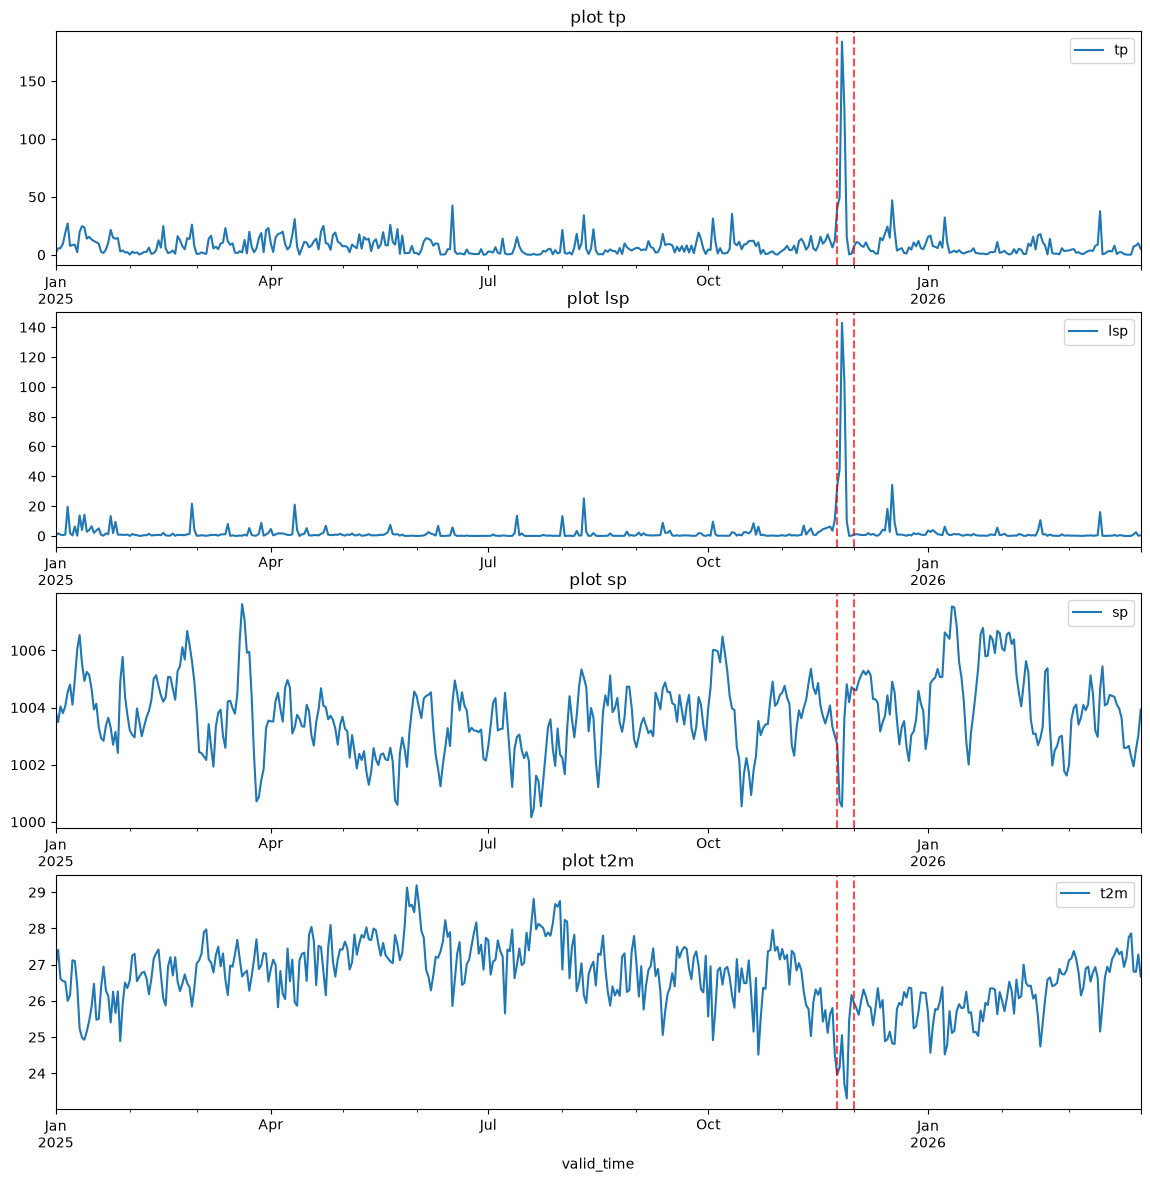

In [21]:
# Calculate the mean for each valid_time
df_medan_mean_time = df_medan.groupby('valid_time').mean().reset_index()
display(df_medan_mean_time)

# Plotting daily total precipitation in Medan
daily_tp = df_medan_mean_time[['valid_time', 'tp','lsp','sp','t2m']].copy()
daily_tp[['tp','lsp']] = daily_tp[['tp','lsp']] * 1000  # Convert from meters to millimeters
daily_tp['sp'] = daily_tp['sp'] / 100  # Convert from Pa to hPa
daily_tp['t2m'] = daily_tp['t2m'] - 273.15
display(daily_tp)

# Plot with subplots
fig, axes = plt.subplots(4, 1, figsize=(14,14))
for i, col in enumerate (['tp','lsp','sp','t2m']):
    daily_tp.plot(kind='line', x='valid_time', y=col, 
                  title=f'plot {col}', ax=axes[i])

# Add vertical lines to each subplot
for ax in axes:
    ax.axvline(x=pd.Timestamp('2025-11-24'), color='red', linestyle='--', alpha=0.7)
    ax.axvline(x=pd.Timestamp('2025-12-01'), color='red', linestyle='--', alpha=0.7)

Tabel berikut merinci kepanjangan dari singkatan nama variabel pada dataset `ds` beserta satuannya, diformat menggunakan LaTeX untuk keperluan ilmiah:

Daftar Variabel Dataset ERA5 beserta Kepanjangan dan Satuannya
1. u10      : 10 metre U wind component $(m/s)$ 
2. v10      : 10 metre V wind component $(m/s)$ 
3. u100     : 100 metre U wind component $(m/s)$ 
4. v100     : 100 metre V wind component $(m/s)$ 
5. v10n     : 10 metre V wind component (neutral) $(m/s)$ 
6. t2m      : 2 metre temperature $(Kelvin)$
7. cp       : Convective precipitation $(meter)$
8. crr      : Convective rain rate $(kg/m^{2}.s)$
9. cvh      : Convective precipitation rate $(kg/m^{2}.s)$
10. lsp     : Large scale precipitation $(meter)$
11. lspf    : Large scale precipitation rate $(kg/m^{2}.s)$
12. lsrr    : Large scale rain rate $(kg/m^{2}.s)$
13. cvl     : Convective snow rate $(kg/m^{2}.s)$
14. msl     : Mean sea level pressure $(Pascal)$
15. ro      : Runoff $(meter)$
16. sst     : Sea surface temperature $(Kelvin)$
17. skt     : Skin temperature $(Kelvin)$
18. sp      : Surface pressure $(Pascal)$
19. sro     : Surface runoff $(meter)$
20. tcc     : Total cloud cover (0 - 1)
21. tclw    : Total column liquid water $(kg/m^{2})$
22. tcrw    : Total column rain water $(kg/m^{2})$
23. tp      : Total precipitation $(meter)$
24. tvh     : Total column vertically integrated heat/moisture -
25. tvl     : Total column vertically integrated liquid -
26. swvl1   : Soil water level 1 $(m^3.m^{-3})$
27. swvl2   : Soil water level 2 $(m^3.m^{-3})$
28. swvl3   : Soil water level 3 $(m^3.m^{-3})$
29. swvl4   : Soil water level 4 $(m^3.m^{-3})$

In [6]:
# merubah satuan dari data ERA5
ds_copy = ds.copy()
# untuk total precipitation (tp) dan large scale precipitation (lsp) dari meter ke millimeter
ds_copy[['tp','lsp']] = ds_copy[['tp','lsp']] * 1000  # Convert from meters to millimeters
# untuk surface pressure (sp) dan mean sea level pressure (msl) dari hPa ke Pa
ds_copy[['sp','msl']] = ds_copy[['sp','msl']] * 100  # Convert from hPa to Pa


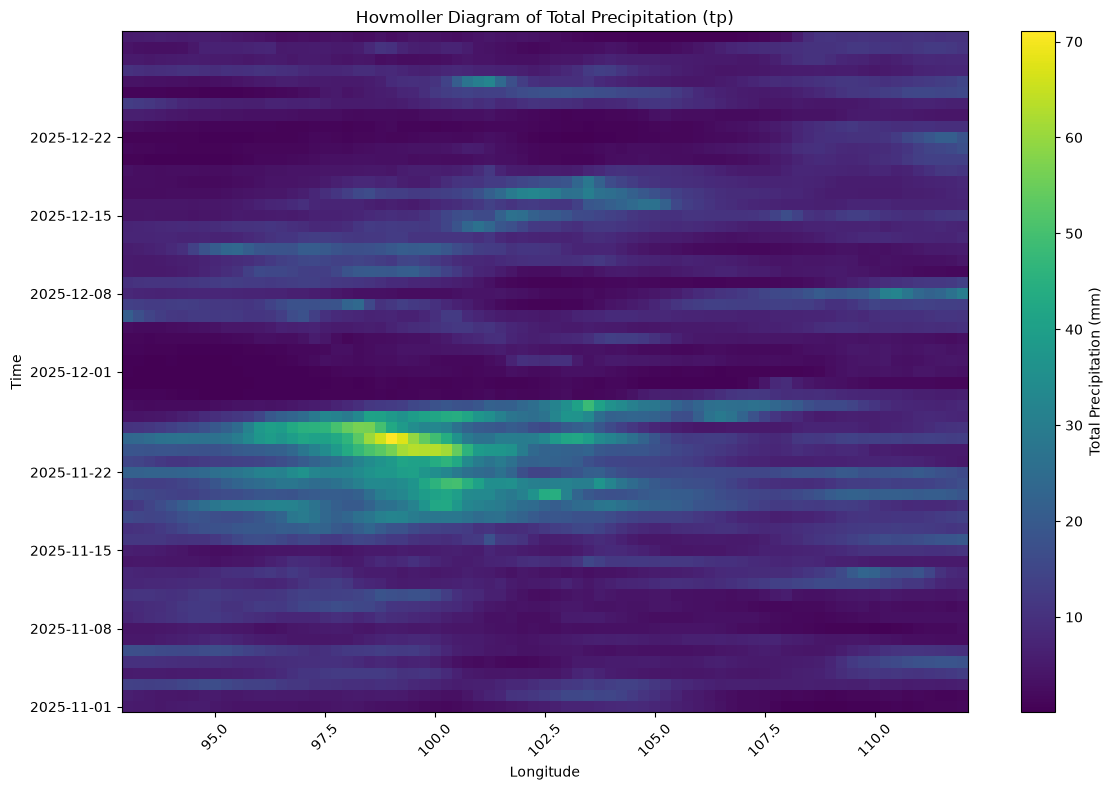

In [7]:
# Create Hovmoller diagram with longitude on x-axis and time on y-axis for variable tp
fig, ax = plt.subplots(figsize=(12, 8))

# filter waktu valid_time between 2025-11-01 and 2025-12-31
ds_filtered = ds_copy.sel(valid_time=slice('2025-11-01', '2025-12-31'))

# Plot the Hovmoller diagram
im = ax.pcolormesh(ds_filtered.longitude, ds_filtered.valid_time, ds_filtered.tp.mean(dim='latitude'), cmap='viridis', shading='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Precipitation (mm)')

# Set labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Time')
ax.set_title('Hovmoller Diagram of Total Precipitation (tp)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

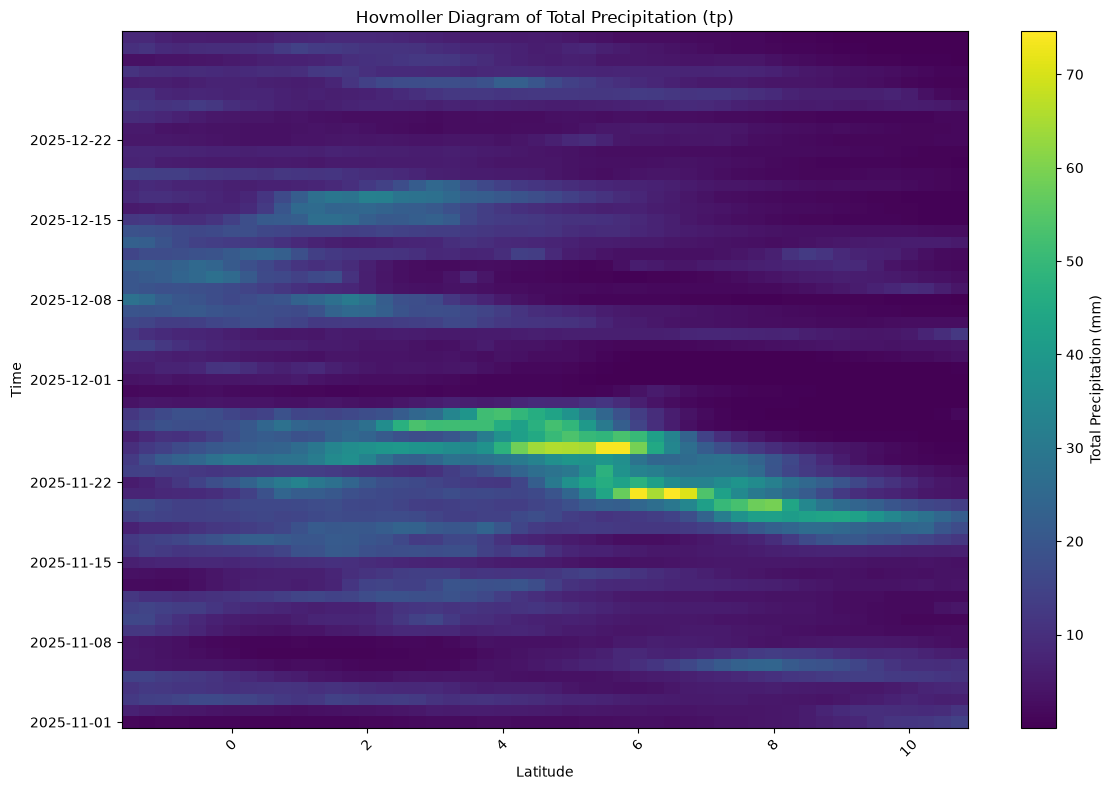

In [8]:
# Create Hovmoller diagram with longitude on x-axis and time on y-axis for variable tp
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the Hovmoller diagram
im = ax.pcolormesh(ds_filtered.latitude, ds_filtered.valid_time, ds_filtered.tp.mean(dim='longitude'), cmap='viridis', shading='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Precipitation (mm)')

# Set labels and title
ax.set_xlabel('Latitude')
ax.set_ylabel('Time')
ax.set_title('Hovmoller Diagram of Total Precipitation (tp)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

In [9]:
# membuat nama variabel yang ada di dataset
ds_keys = ds_copy._variables.keys()
var_names = [var for var in ds_keys if var not in ['latitude', 'longitude', 'valid_time','number']]
var_long_names = [ds[var].long_name for var in var_names]
var_name = dict(zip(var_names, var_long_names))
var_name

{'u100': '100 metre U wind component',
 'v100': '100 metre V wind component',
 'u10n': '10 metre u-component of neutral wind',
 'u10': '10 metre U wind component',
 'v10n': '10 metre v-component of neutral wind',
 'v10': '10 metre V wind component',
 'd2m': '2 metre dewpoint temperature',
 't2m': '2 metre temperature',
 'cp': 'Convective precipitation',
 'crr': 'Convective rain rate',
 'cvh': 'High vegetation cover',
 'lsp': 'Large-scale precipitation',
 'lspf': 'Large-scale precipitation fraction',
 'lsrr': 'Large scale rain rate',
 'cvl': 'Low vegetation cover',
 'msl': 'Mean sea level pressure',
 'ro': 'Runoff',
 'sst': 'Sea surface temperature',
 'skt': 'Skin temperature',
 'sp': 'Surface pressure',
 'sro': 'Surface runoff',
 'tcc': 'Total cloud cover',
 'tclw': 'Total column cloud liquid water',
 'tcrw': 'Total column rain water',
 'tp': 'Total precipitation',
 'tvh': 'Type of high vegetation',
 'tvl': 'Type of low vegetation',
 'swvl1': 'Volumetric soil water layer 1',
 'swvl2': 

In [ ]:
# Create Hovmoller diagrams for all variables in the dataset
for var in var_names:
    # Create Hovmoller diagram with longitude on x-axis and time on y-axis for each variable
    fig, ax = plt.subplots(figsize=(12, 8))

    # Filter the dataset for the desired time range (optional)
    ds_filtered = ds_copy
    #ds_filtered = ds_copy.sel(valid_time=slice('2025-11-01', '2025-12-31'))

    # Plot the Hovmoller diagram
    im = ax.pcolormesh(ds_filtered.latitude, ds_filtered.valid_time, ds_filtered[var].mean(dim='longitude'), cmap='viridis', shading='auto')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    # Get the units from the actual variable in the dataset
    var_units = ds_copy[var].attrs.get('units', '')  # Use .attrs.get to safely get units if they exist
    cbar.set_label(f'{var_name[var]} ({var_units})')

    # Set labels and title
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Time')
    ax.set_title(f'Hovmoller Diagram of {var_name[var]}')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.savefig(f'D:/ERA5_REANALYSIS/Senyar_Cylone/Hovmuller_plot/Hovmoller_{var_name[var]}_Latitude.png')  # Save the figure as a PNG file

## Analisis Fourier Transform: Frekuensi vs Longitude (Variabel tp)
Analisis ini menggunakan Transformasi Fourier untuk mengidentifikasi dominansi frekuensi dari total presipitasi (`tp`) pada setiap bujur (longitude). Plot 2D histogram menampilkan sumbu x = longitude, sumbu y = frekuensi, dan warna menunjukkan kekuatan sinyal (power).

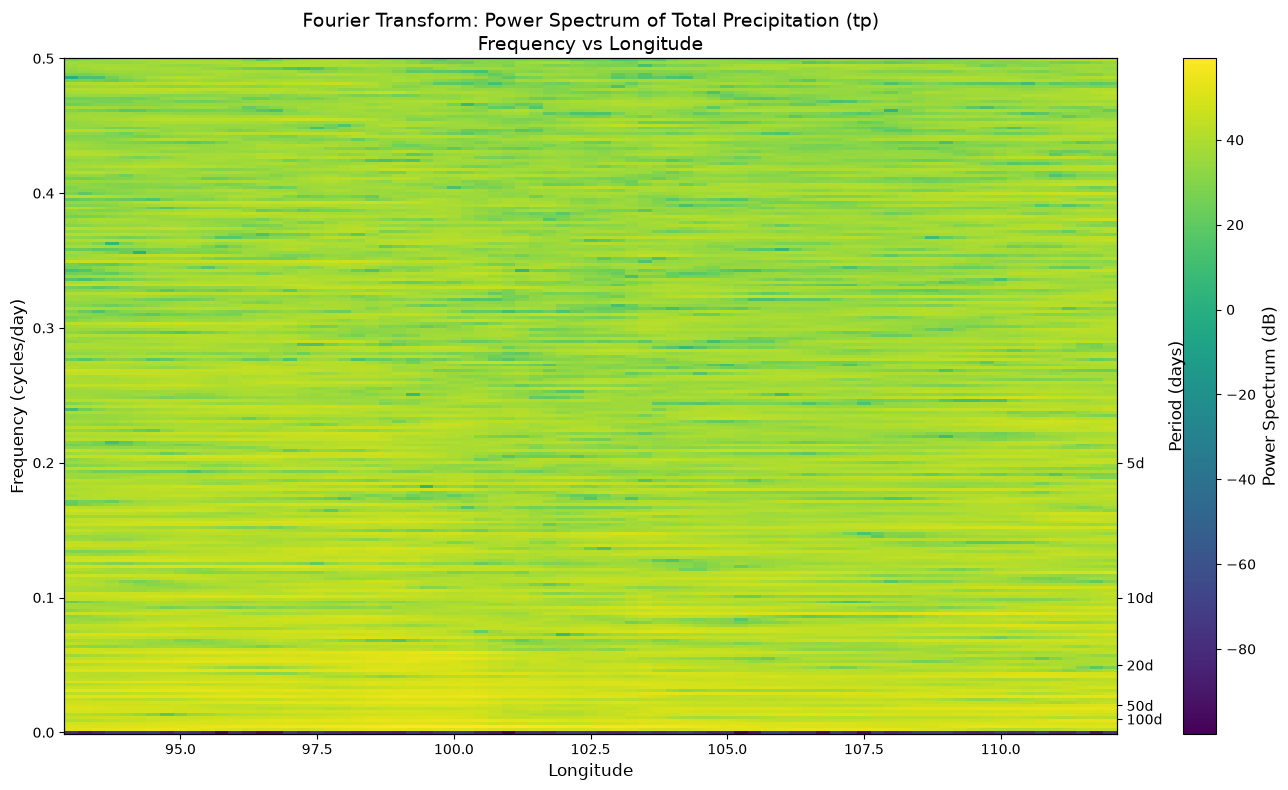

Dimensi data tp: ('valid_time', 'longitude')
Jumlah longitude: 77
Jumlah waktu: 455
Jumlah frekuensi: 228
Rentang frekuensi: 0.0022 - 0.4989 cycles/day
Rentang longitude: 93.00 - 112.00


In [26]:
# Analisis Fourier Transform: Frekuensi vs Longitude untuk variabel tp
# Menggunakan ds_copy yang sudah dikonversi satuannya (tp dalam mm)

# Ambil data tp, rata-rata sepanjang latitude untuk setiap longitude
tp_lon_time = ds_copy['tp'].mean(dim='latitude')  # dimensi: (valid_time, longitude)

# Ambil informasi dimensi
lons = tp_lon_time.longitude.values
times = tp_lon_time.valid_time.values
n_time = len(times)

# Hitung selang waktu harian (asumsi data harian)
dt = 1.0  # hari

# Hitung FFT untuk setiap longitude
frequencies = np.fft.rfftfreq(n_time, d=dt)  # frekuensi dalam cycles/hari
n_freq = len(frequencies)

# Inisialisasi array power spectrum 2D (longitude x frequency)
power_spectrum = np.zeros((n_freq, len(lons)))

# Hitung power spectrum untuk setiap longitude
for i, lon in enumerate(lons):
    tp_series = tp_lon_time.sel(longitude=lon).values
    # Hilangkan mean (detrending sederhana)
    tp_series = tp_series - np.nanmean(tp_series)
    # Ganti NaN dengan 0 jika ada
    tp_series = np.nan_to_num(tp_series, nan=0.0)
    # Hitung FFT
    fft_vals = np.fft.rfft(tp_series)
    # Power spectrum = |FFT|^2
    power_spectrum[:, i] = np.abs(fft_vals) ** 2

# Konversi ke dB untuk visualisasi yang lebih baik
power_spectrum_db = 10 * np.log10(power_spectrum + 1e-10)  # tambah epsilon untuk hindari log(0)

# === Visualisasi 2D Histogram (Pcolormesh) ===
fig, ax = plt.subplots(figsize=(14, 8))

# Plot 2D dengan longitude di sumbu x dan frekuensi di sumbu y
im = ax.pcolormesh(lons, frequencies, power_spectrum_db, cmap='viridis', shading='auto')

# Tambahkan colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Power Spectrum (dB)', fontsize=12)

# Set label dan judul
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
ax.set_title('Fourier Transform: Power Spectrum of Total Precipitation (tp)\nFrequency vs Longitude', fontsize=14)

# Tambahkan garis periode dominan sebagai referensi
# Periode = 1/frekuensi
period_ticks = [1, 2, 5, 10, 20, 50, 100]  # hari
period_labels = ['1d', '2d', '5d', '10d', '20d', '50d', '100d']
valid_periods = [p for p in period_ticks if 1.0/p >= frequencies[1] and 1.0/p <= frequencies[-1]]
valid_labels = [period_labels[i] for i, p in enumerate(period_ticks) if p in valid_periods]

if valid_periods:
    valid_freqs = [1.0/p for p in valid_periods]
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(valid_freqs)
    ax2.set_yticklabels(valid_labels, fontsize=10)
    ax2.set_ylabel('Period (days)', fontsize=12)

# Tampilkan plot
plt.tight_layout()
plt.savefig('D:/ERA5_REANALYSIS/Senyar_Cylone/Fourier_Analysis/FFT_tp_Frequency_vs_Longitude.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dimensi data tp: {tp_lon_time.dims}")
print(f"Jumlah longitude: {len(lons)}")
print(f"Jumlah waktu: {n_time}")
print(f"Jumlah frekuensi: {n_freq}")
print(f"Rentang frekuensi: {frequencies[1]:.4f} - {frequencies[-1]:.4f} cycles/day")
print(f"Rentang longitude: {lons.min():.2f} - {lons.max():.2f}")

## Analisis Fourier Transform: Frekuensi vs Longitude (Variabel skt)
Analisis ini menggunakan Transformasi Fourier untuk mengidentifikasi dominansi frekuensi dari Skin Temperature (`skt`) pada setiap bujur (longitude). Plot 2D histogram menampilkan sumbu x = longitude, sumbu y = frekuensi, dan warna menunjukkan kekuatan sinyal (power).

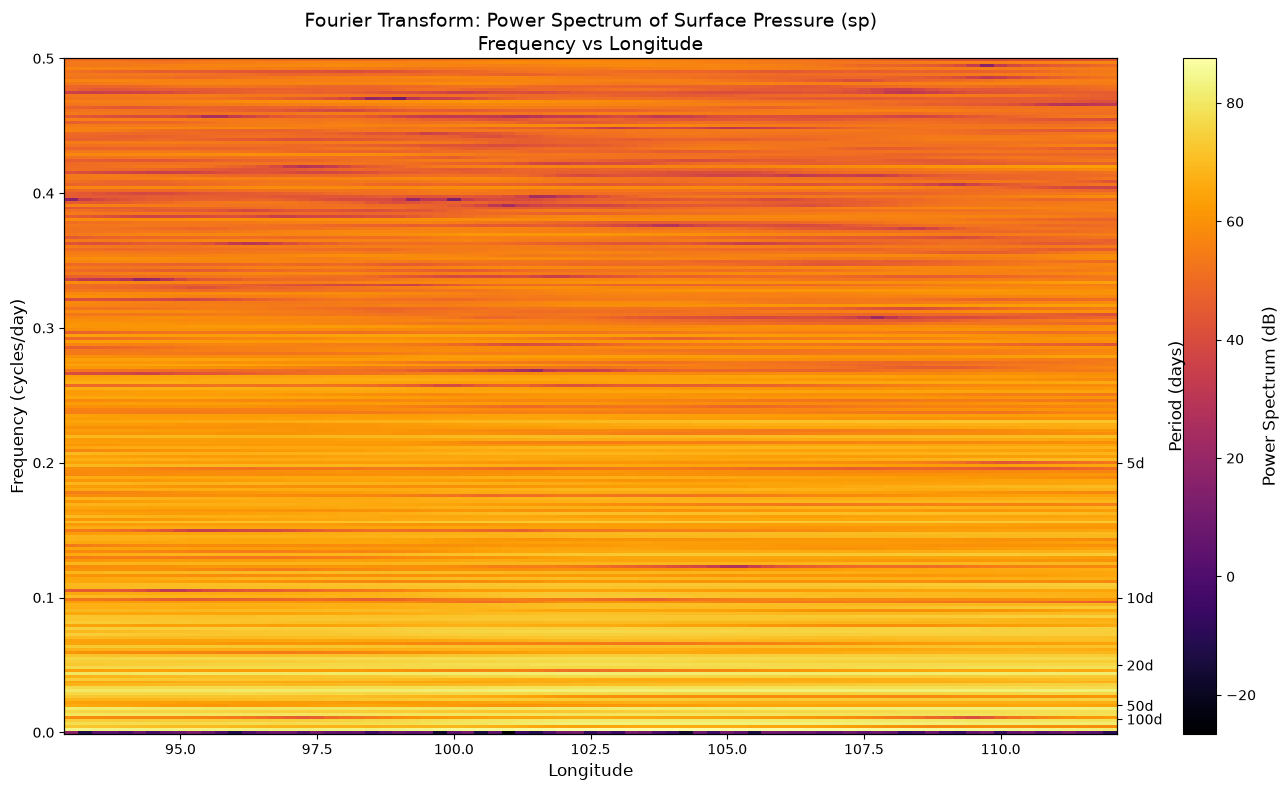

Dimensi data skt: ('valid_time', 'longitude')
Jumlah longitude: 77
Jumlah waktu: 455
Jumlah frekuensi: 228
Rentang frekuensi: 0.0022 - 0.4989 cycles/day
Rentang longitude: 93.00 - 112.00


In [41]:
# Analisis Fourier Transform: Frekuensi vs Longitude untuk variabel skt (Skin Temperature)

# Ambil data skt, rata-rata sepanjang latitude untuk setiap longitude
skt_lon_time = ds['sp'].mean(dim='latitude')  # dimensi: (valid_time, longitude)

# Ambil informasi dimensi
lons = skt_lon_time.longitude.values
times = skt_lon_time.valid_time.values
n_time = len(times)

# Hitung selang waktu harian (asumsi data harian)
dt = 1.0  # hari

# Hitung FFT untuk setiap longitude
frequencies = np.fft.rfftfreq(n_time, d=dt)  # frekuensi dalam cycles/hari
n_freq = len(frequencies)

# Inisialisasi array power spectrum 2D (longitude x frequency)
power_spectrum_skt = np.zeros((n_freq, len(lons)))

# Hitung power spectrum untuk setiap longitude
for i, lon in enumerate(lons):
    skt_series = skt_lon_time.sel(longitude=lon).values
    # Hilangkan mean (detrending sederhana)
    skt_series = skt_series - np.nanmean(skt_series)
    # Ganti NaN dengan 0 jika ada
    skt_series = np.nan_to_num(skt_series, nan=0.0)
    # Hitung FFT
    fft_vals = np.fft.rfft(skt_series)
    # Power spectrum = |FFT|^2
    power_spectrum_skt[:, i] = np.abs(fft_vals) ** 2

# Konversi ke dB untuk visualisasi yang lebih baik
power_spectrum_skt_db = 10 * np.log10(power_spectrum_skt + 1e-10)

# === Visualisasi 2D Histogram (Pcolormesh) ===
fig, ax = plt.subplots(figsize=(14, 8))

# Plot 2D dengan longitude di sumbu x dan frekuensi di sumbu y
im = ax.pcolormesh(lons, frequencies, power_spectrum_skt_db, cmap='inferno', shading='auto')

# Tambahkan colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Power Spectrum (dB)', fontsize=12)

# Set label dan judul
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
ax.set_title('Fourier Transform: Power Spectrum of Surface Pressure (sp)\nFrequency vs Longitude', fontsize=14)

# Tambahkan garis periode dominan sebagai referensi (sumbu kanan)
# Periode = 1/frekuensi
period_ticks = [1, 2, 5, 10, 20, 50, 100]  # hari
period_labels = ['1d', '2d', '5d', '10d', '20d', '50d', '100d']
valid_periods = [p for p in period_ticks if 1.0/p >= frequencies[1] and 1.0/p <= frequencies[-1]]
valid_labels = [period_labels[i] for i, p in enumerate(period_ticks) if p in valid_periods]

if valid_periods:
    valid_freqs = [1.0/p for p in valid_periods]
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(valid_freqs)
    ax2.set_yticklabels(valid_labels, fontsize=10)
    ax2.set_ylabel('Period (days)', fontsize=12)

# Tampilkan plot
plt.tight_layout()
plt.savefig('D:/ERA5_REANALYSIS/Senyar_Cylone/Fourier_Analysis/FFT_sp_Frequency_vs_Longitude.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dimensi data skt: {skt_lon_time.dims}")
print(f"Jumlah longitude: {len(lons)}")
print(f"Jumlah waktu: {n_time}")
print(f"Jumlah frekuensi: {n_freq}")
print(f"Rentang frekuensi: {frequencies[1]:.4f} - {frequencies[-1]:.4f} cycles/day")
print(f"Rentang longitude: {lons.min():.2f} - {lons.max():.2f}")